<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/notebook_poisson_transformada_inversa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Generación de una variable aleatoria Poisson**

Se implementa el método de la **transformada inversa** para simular una variable aleatoria discreta con distribución Poisson.

La idea principal es usar la función de distribución acumulada:

$$F(i)=P(X\leq i)$$

y generar un número aleatorio uniforme $U\sim U(0,1)$. Después se busca el primer entero $i$ tal que:
$$U < F(i)$$

Ese valor entero será la simulación de la variable aleatoria $X$.

Una variable $X$ es Poisson con media $\lambda$ si:

$$P_i=P(X=i)=e^{-\lambda}\frac{\lambda^i}{i!},
\qquad i=0,1,\ldots$$

Para simular esta variable usamos la identidad:

$$P_{i+1}=\frac{\lambda}{i+1}P_i,
\qquad i\geq 0$$

Esta relación permite calcular las probabilidades de manera recursiva sin tener que calcular factoriales.

### Pseudocódigo

Repetir:

1. Generar $R\sim U(0,1)$
2. Tomar

$$i=0,\qquad p=e^{-\lambda},\qquad F=p$$

3. Si $U<F$, hacer $X=i$ y terminar.
4. Actualizar:

$$p=\frac{\lambda p}{i+1},
\qquad
F=F+p,
\qquad
i=i+1$$

5. Ir al paso 3.

##  Interpretación y utilidad de la distribución Poisson

Una variable aleatoria $X$ tiene distribución Poisson con parámetro $\lambda>0$ cuando modela el número de ocurrencias de un evento en un intervalo fijo de tiempo, espacio o región, bajo la idea de que los eventos ocurren de manera independiente y con una tasa promedio constante.

Se escribe:
$$X\sim \operatorname{Poisson}(\lambda)$$

donde $\lambda$ representa el número promedio de ocurrencias esperadas en el intervalo analizado.

Algunos ejemplos donde puede utilizarse la distribución Poisson son:

- número de clientes que llegan a una tienda en cierto tiempo;
- número de llamadas que recibe un centro de atención por minuto;
- número de defectos encontrados en un lote de producción;
- número de accidentes en una zona durante cierto periodo;
- número de partículas emitidas por una fuente radiactiva en un intervalo de tiempo.

Esta distribución es útil en simulación porque permite representar conteos discretos de eventos aleatorios. Además, es importante porque su esperanza y varianza son iguales:

$$E(X)=\lambda,
\qquad
\operatorname{Var}(X)=\lambda.$$

Por eso, cuando se observa un fenómeno de conteo cuyo promedio y variabilidad son cercanos, la distribución Poisson suele ser una primera opción de modelado.

## Demostración de la identidad recursiva

Partimos de la probabilidad de una variable Poisson:

$$P_i=e^{-\lambda}\frac{\lambda^i}{i!}$$

Ahora calculamos $P_{i+1}$:
$$P_{i+1}=e^{-\lambda}\frac{\lambda^{i+1}}{(i+1)!}$$

Como
$$(i+1)!=(i+1)i!,$$

entonces:
$$P_{i+1}
=
e^{-\lambda}
\frac{\lambda^{i+1}}{(i+1)i!}$$

Separamos un factor $\lambda$:
$$P_{i+1}
=
\frac{\lambda}{i+1}
e^{-\lambda}\frac{\lambda^i}{i!}$$

Pero
$$e^{-\lambda}\frac{\lambda^i}{i!}=P_i$$


Por lo tanto:
$$P_{i+1}=\frac{\lambda}{i+1}P_i$$

Esta identidad es la que se utiliza en el programa para actualizar $p$ en cada iteración.

In [10]:
import random
import math
from collections import Counter

import matplotlib.pyplot as plt

In [11]:
def poisson_transformada_inversa(lam, mostrar_pasos=False):

    if lam <= 0:
        raise ValueError("El parámetro lambda debe ser positivo.")

    # Paso 1: generar U ~ U(0,1)
    U = random.random()

    # Paso 2: valores iniciales
    i = 0
    p = math.exp(-lam)  # P(X = 0)
    F = p              # F(0) = P(X <= 0)

    pasos = []
    if mostrar_pasos:
        pasos.append([i, p, F, U])

    # Paso 3: buscar el primer i tal que U < F
    while U >= F:
        # Paso 4: actualizar p usando la identidad recursiva
        p = (lam * p) / (i + 1)

        # Actualizar la acumulada
        F = F + p

        # Pasar al siguiente valor de i
        i = i + 1

        if mostrar_pasos:
            pasos.append([i, p, F, U])

    if mostrar_pasos:
        return i, U, pasos

    return i

In [12]:
lam = 3

x, U, pasos = poisson_transformada_inversa(lam, mostrar_pasos=True)

print(f"lambda = {lam}")
print(f"U generado = {U:.6f}")
print(f"Valor simulado: X = {x}")

lambda = 3
U generado = 0.764170
Valor simulado: X = 4


In [13]:
# Tabla de iteraciones
encabezados = ["i", "p = P(X=i)", "F = P(X<=i)", "U"]

try:
    from tabulate import tabulate
    print(tabulate(pasos, headers=encabezados, tablefmt="grid", floatfmt=".6f"))
except ImportError:
    print(encabezados)
    for fila in pasos:
        print([fila[0], round(fila[1], 6), round(fila[2], 6), round(fila[3], 6)])

+-----+--------------+---------------+----------+
|   i |   p = P(X=i) |   F = P(X<=i) |        U |
+=====+==============+===============+==========+
|   0 |     0.049787 |      0.049787 | 0.764170 |
+-----+--------------+---------------+----------+
|   1 |     0.149361 |      0.199148 | 0.764170 |
+-----+--------------+---------------+----------+
|   2 |     0.224042 |      0.423190 | 0.764170 |
+-----+--------------+---------------+----------+
|   3 |     0.224042 |      0.647232 | 0.764170 |
+-----+--------------+---------------+----------+
|   4 |     0.168031 |      0.815263 | 0.764170 |
+-----+--------------+---------------+----------+


In [14]:
# Función auxiliar para calcular la probabilidad teórica P(X=k)
# usando también la relación recursiva.

def poisson_pmf_recursiva(lam, k):
    if k < 0:
        return 0

    p = math.exp(-lam)  # P_0

    for i in range(k):
        p = (lam * p) / (i + 1)

    return p

In [15]:
lam = 3
n = 10000

muestra = [poisson_transformada_inversa(lam) for _ in range(n)]

print(f"Se generaron {n} valores de una variable Poisson con lambda = {lam}.")

print(muestra[:20])

Se generaron 10000 valores de una variable Poisson con lambda = 3.
[0, 3, 6, 3, 3, 3, 6, 3, 3, 0, 3, 2, 4, 4, 2, 0, 2, 5, 4, 5]


In [16]:
# Comparación

conteos = Counter(muestra)

valor_maximo = max(max(muestra), int(lam + 4 * math.sqrt(lam)))
valores = list(range(valor_maximo + 1))

tabla_comparacion = []

for k in valores:
    frecuencia_absoluta = conteos.get(k, 0)
    frecuencia_relativa = frecuencia_absoluta / n
    prob_teorica = poisson_pmf_recursiva(lam, k)

    tabla_comparacion.append([
        k,
        frecuencia_absoluta,
        frecuencia_relativa,
        prob_teorica
    ])

encabezados = ["k", "Frecuencia absoluta", "Frecuencia relativa", "P(X=k) teórica"]

try:
    from tabulate import tabulate
    print(tabulate(tabla_comparacion, headers=encabezados, tablefmt="grid", floatfmt=".6f"))
except ImportError:
    print(encabezados)
    for fila in tabla_comparacion:
        print(fila)

+-----+-----------------------+-----------------------+------------------+
|   k |   Frecuencia absoluta |   Frecuencia relativa |   P(X=k) teórica |
+=====+=======================+=======================+==================+
|   0 |                   495 |              0.049500 |         0.049787 |
+-----+-----------------------+-----------------------+------------------+
|   1 |                  1487 |              0.148700 |         0.149361 |
+-----+-----------------------+-----------------------+------------------+
|   2 |                  2224 |              0.222400 |         0.224042 |
+-----+-----------------------+-----------------------+------------------+
|   3 |                  2228 |              0.222800 |         0.224042 |
+-----+-----------------------+-----------------------+------------------+
|   4 |                  1700 |              0.170000 |         0.168031 |
+-----+-----------------------+-----------------------+------------------+
|   5 |                  

In [17]:
media_simulada = sum(muestra) / n
varianza_simulada = sum((x - media_simulada)**2 for x in muestra) / (n - 1)

print(f"Media simulada: {media_simulada:.6f}")
print(f"Media teórica:  {lam:.6f}")
print()
print(f"Varianza simulada: {varianza_simulada:.6f}")
print(f"Varianza teórica:  {lam:.6f}")

Media simulada: 3.008400
Media teórica:  3.000000

Varianza simulada: 2.996829
Varianza teórica:  3.000000


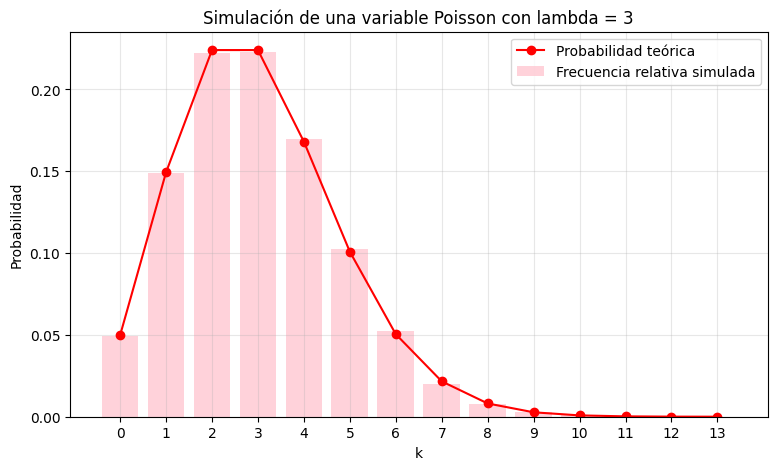

In [20]:
frecuencias_relativas = [conteos.get(k, 0) / n for k in valores]
probabilidades_teoricas = [poisson_pmf_recursiva(lam, k) for k in valores]

plt.figure(figsize=(9, 5))

plt.bar(valores, frecuencias_relativas,color="pink", alpha=0.7, label="Frecuencia relativa simulada")
plt.plot(valores, probabilidades_teoricas,color='red' ,marker="o", label="Probabilidad teórica")

plt.title(f"Simulación de una variable Poisson con lambda = {lam}")
plt.xlabel("k")
plt.ylabel("Probabilidad")
plt.xticks(valores)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Conclusión

El método de la transformada inversa permite simular una variable aleatoria discreta usando probabilidades acumuladas. En el caso de la distribución Poisson, el procedimiento se vuelve eficiente gracias a la identidad:

$$P_{i+1}=\frac{\lambda}{i+1}P_i$$



Al repetir este procedimiento muchas veces, las frecuencias relativas simuladas se aproximan a las probabilidades teóricas de la distribución Poisson.